In [2]:
import os, random
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import pandas as pd
from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import yfinance as yf

df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01"
)

/tmp/ipykernel_581/1901260772.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192600,24.659502,23.754464,24.648438,212818400
2015-01-05,23.511065,24.042138,23.325190,23.962477,257142000
2015-01-06,23.513277,23.772175,23.152589,23.575235,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2516 non-null   float64
 1   (High, AAPL)    2516 non-null   float64
 2   (Low, AAPL)     2516 non-null   float64
 3   (Open, AAPL)    2516 non-null   float64
 4   (Volume, AAPL)  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,93.684877,94.594694,92.673089,93.598213,1.170853e+08
std,65.319931,65.912255,64.634534,65.239867,6.839614e+07
min,20.565874,20.868639,20.367820,20.488465,2.323470e+07
25%,35.157628,35.554813,34.780268,35.177794,7.105610e+07
50%,64.268627,64.822327,63.468161,64.109468,1.003646e+08
75%,149.955391,151.700214,147.992755,149.778508,1.426216e+08
max,257.375580,258.448740,255.994420,256.550862,6.488252e+08


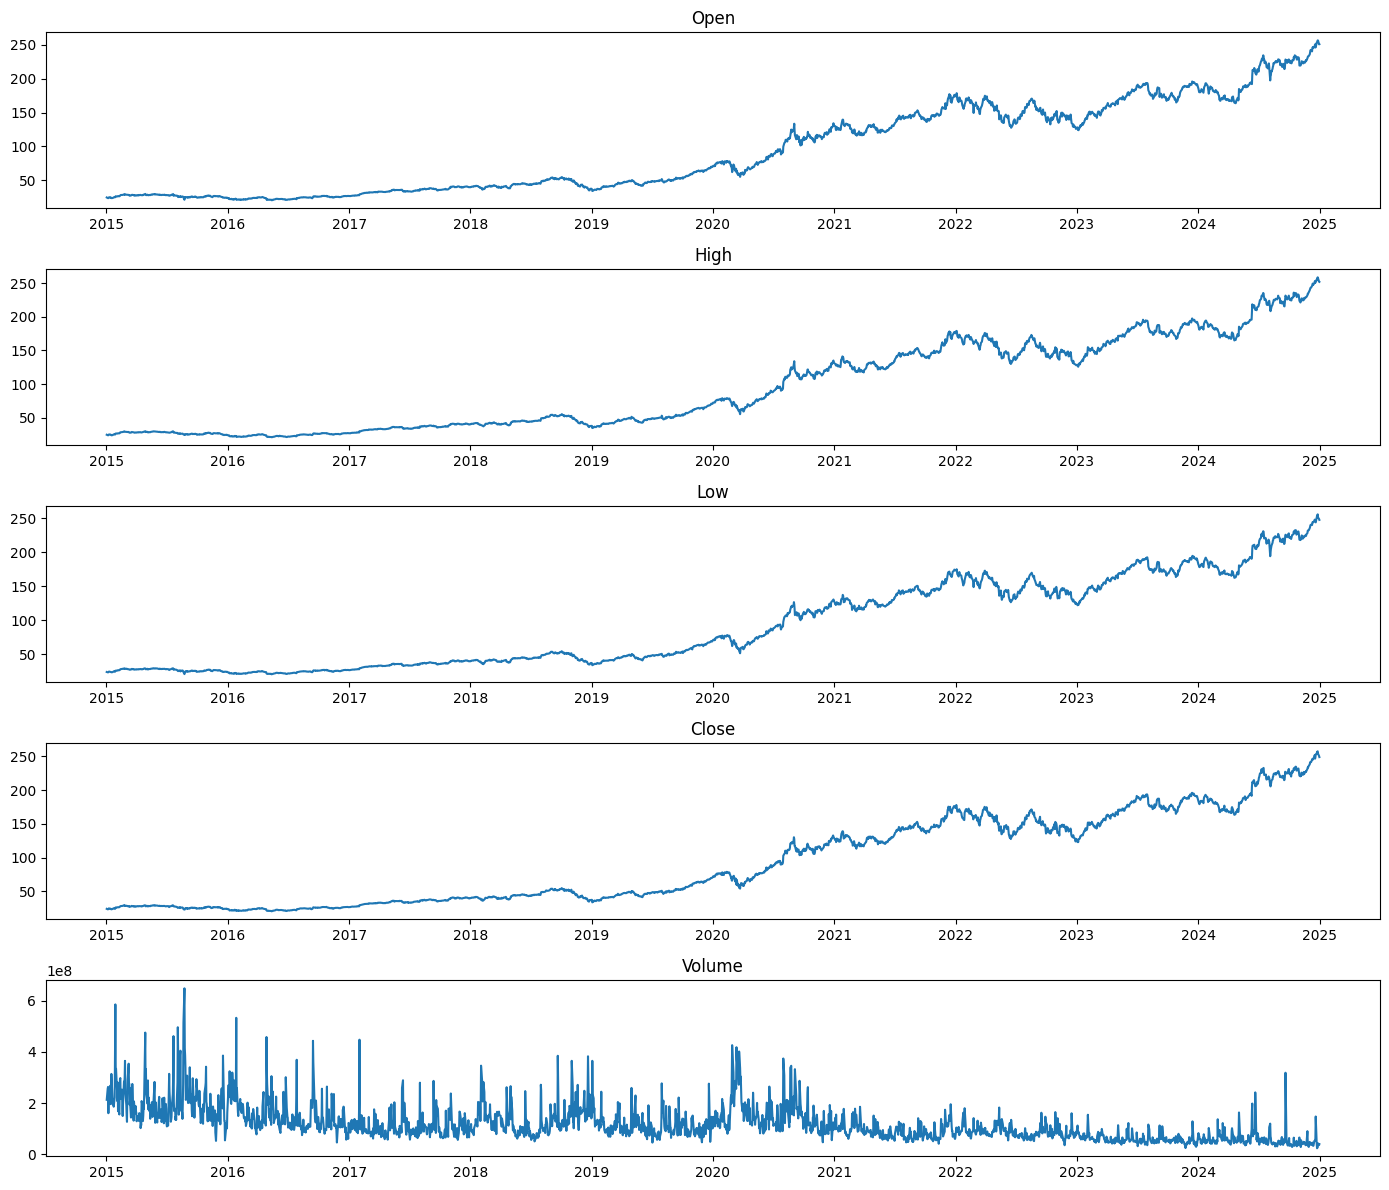

In [7]:
fig, ax = plt.subplots(5, 1, figsize=(14,12))

ax[0].plot(df['Open'])
ax[0].set_title('Open')

ax[1].plot(df['High'])
ax[1].set_title('High')

ax[2].plot(df['Low'])
ax[2].set_title('Low')

ax[3].plot(df['Close'])
ax[3].set_title('Close')

ax[4].plot(df['Volume'])
ax[4].set_title('Volume')

plt.tight_layout()
plt.show()

In [8]:
df["Return"]=df["Close"].pct_change()

<Axes: xlabel='Return', ylabel='Count'>

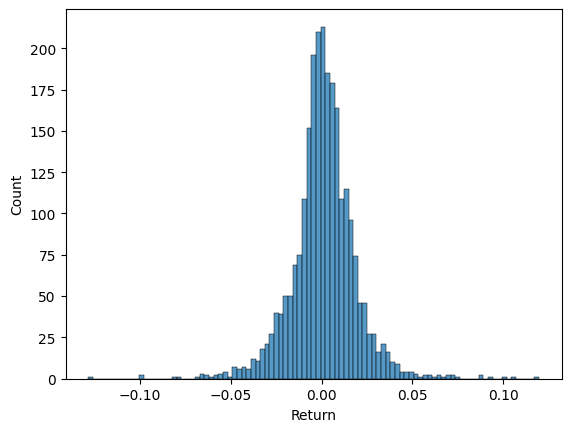

In [9]:
sns.histplot(df["Return"])

In [10]:
volatility = df['Return'].std()
print(volatility)

0.01792921836780371


In [11]:
mean_return = df['Return'].mean()
print(mean_return)

0.0010878563941136177


In [12]:
df.columns = df.columns.get_level_values(0)

In [13]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Open: 0 outliers
High: 0 outliers
Low: 0 outliers
Close: 0 outliers
Volume: 128 outliers


The 20-day moving average closely followed short-term price movements, while the 50-day and 200-day moving averages captured medium- and long-term trends.

Several Golden Cross events were observed where MA50 crossed above MA200, indicating potential bullish momentum. Conversely, Death Cross events suggested bearish market sentiment.

The stock remained above its MA200 for extended periods, indicating a strong long-term upward trend.

In [14]:
df['MA20'] = df['Close'].rolling(window=20).mean()

df['MA50'] = df['Close'].rolling(window=50).mean()

df['MA200'] = df['Close'].rolling(window=200).mean()

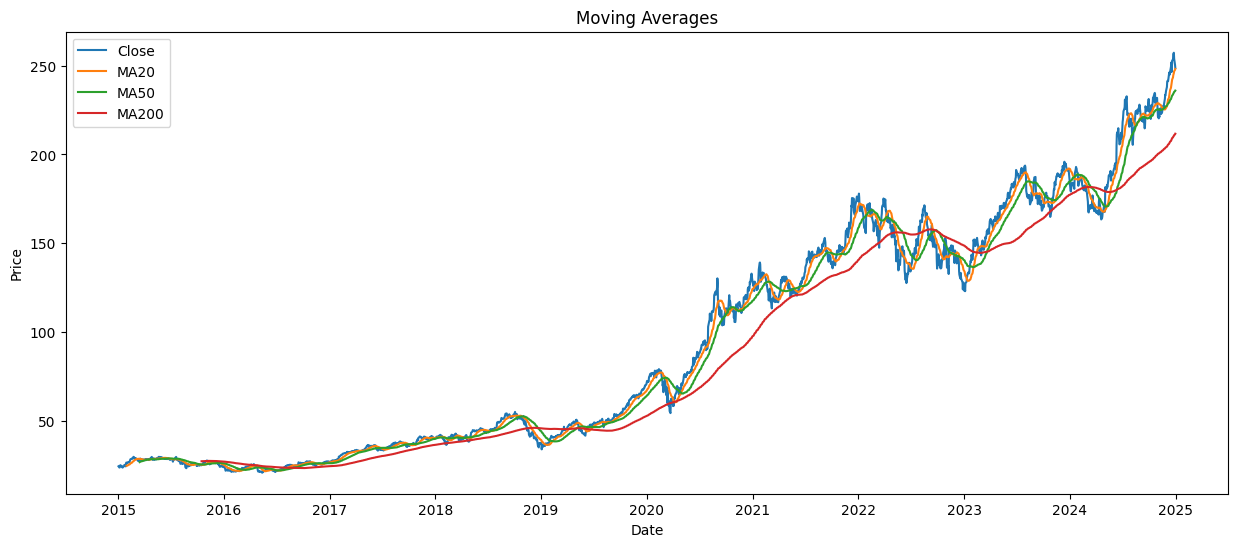

In [15]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df['Close'], label='Close')

plt.plot(df.index, df['MA20'], label='MA20')

plt.plot(df.index, df['MA50'], label='MA50')

plt.plot(df.index, df['MA200'], label='MA200')

plt.title("Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [16]:
# Golden cross is observed because MA50 crosses ABOVE MA200

In [17]:
golden_cross = (
    (df['MA50'] > df['MA200']) &
    (df['MA50'].shift(1) <= df['MA200'].shift(1))
)

print(df[golden_cross].index)

DatetimeIndex(['2016-08-30', '2019-05-06', '2022-09-26', '2023-03-22',
               '2024-06-13'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [18]:
death_cross = (
    (df['MA50'] < df['MA200']) &
    (df['MA50'].shift(1) >= df['MA200'].shift(1))
)

print(df[death_cross].index)

DatetimeIndex(['2018-12-21', '2022-06-03', '2022-10-07', '2024-03-14'], dtype='datetime64[ns]', name='Date', freq=None)


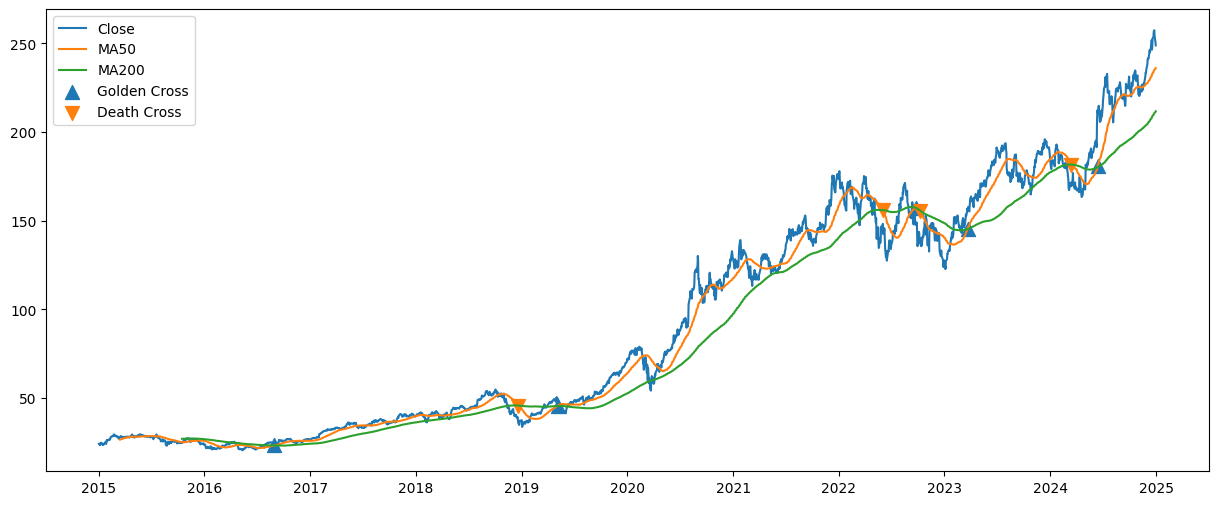

In [19]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df['Close'], label='Close')

plt.plot(df.index, df['MA50'], label='MA50')

plt.plot(df.index, df['MA200'], label='MA200')

plt.scatter(
    df[golden_cross].index,
    df.loc[golden_cross, 'MA50'],
    marker='^',
    s=100,
    label='Golden Cross'
)

plt.scatter(
    df[death_cross].index,
    df.loc[death_cross, 'MA50'],
    marker='v',
    s=100,
    label='Death Cross'
)

plt.legend()

plt.show()

<Axes: xlabel='Price', ylabel='Price'>

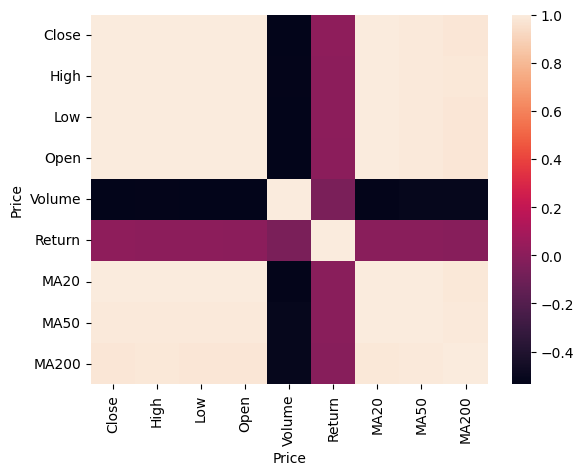

In [20]:
sns.heatmap(df.corr())

 time series analysis, a stationary check is the process of determining whether the statistical properties of your data — such as mean, variance, and autocorrelation — remain constant over time.

Stationarity is important because many forecasting models (like ARIMA) assume that the input time series is stationary.

Types of Stationarity
Strict Stationarity – The entire distribution of the series does not change over time.
Weak (or Covariance) Stationarity – Mean, variance, and autocovariance are constant over time.
Trend Stationarity – The series becomes stationary after removing a deterministic trend.

2. Augmented Dickey-Fuller (ADF) Test


In [21]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the 'Close' price column
result = adfuller(df['Close'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# Interpretation
if result[1] <= 0.05:
    print("✅ The series is stationary.")
else:
    print("❌ The series is non-stationary (fail to reject null hypothesis).")
# Null Hypothesis (H₀): The series is non-stationary.
# Alternative Hypothesis (H₁): The series is stationary.
# p-value ≤ 0.05 → Stationary.

ADF Statistic: 0.7973436440454275
p-value: 0.9915931682420861
Critical Values: {'1%': np.float64(-3.4329527780962255), '5%': np.float64(-2.8626898965523724), '10%': np.float64(-2.567382133955709)}
❌ The series is non-stationary (fail to reject null hypothesis).


In [22]:
df["Volatility"] = (
    df["Return"]
    .rolling(30)
    .std()
)

In [24]:
df["Volatility"]

,Volatility
Date,
2015-01-02,NaN
2015-01-05,NaN
2015-01-06,NaN
2015-01-07,NaN
2015-01-08,NaN
...,...
2024-12-24,0.008616
2024-12-26,0.008575
2024-12-27,0.009190


In [ ]:
# Price Features
# ├── Returns
# ├── Log Returns

# Trend Features
# ├── MA20
# ├── MA50
# ├── MA200
# ├── EMA20
# ├── EMA50

# Momentum Features
# ├── RSI
# ├── MACD
# ├── MACD Signal

# Volatility Features
# ├── Rolling Std (20 days)
# ├── Bollinger Upper
# ├── Bollinger Lower

# Volume Features
# ├── Volume Change %
# ├── Volume MA20

In [25]:
df['Return'] = df['Close'].pct_change()

In [26]:
df['Log_Return'] = np.log(
    df['Close'] / df['Close'].shift(1)
)

In [27]:
df['MA20'] = df['Close'].rolling(20).mean()

df['MA50'] = df['Close'].rolling(50).mean()

df['MA200'] = df['Close'].rolling(200).mean()

In [28]:
#Exponentially moving averages
df['EMA20'] = df['Close'].ewm(
    span=20,
    adjust=False
).mean()

df['EMA50'] = df['Close'].ewm(
    span=50,
    adjust=False
).mean()

In [29]:
df['Volatility20'] = (
    df['Return']
    .rolling(20)
    .std()
)

In [30]:
rolling_mean = df['Close'].rolling(20).mean()

rolling_std = df['Close'].rolling(20).std()

df['BB_Upper'] = (
    rolling_mean + 2 * rolling_std
)

df['BB_Lower'] = (
    rolling_mean - 2 * rolling_std
)

In [31]:
delta = df['Close'].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df['RSI'] = (
    100 - (100 / (1 + rs))
)

In [32]:
ema12 = df['Close'].ewm(
    span=12,
    adjust=False
).mean()

ema26 = df['Close'].ewm(
    span=26,
    adjust=False
).mean()

df['MACD'] = ema12 - ema26

df['MACD_Signal'] = (
    df['MACD']
    .ewm(span=9, adjust=False)
    .mean()
)

In [33]:
df['Volume_Change'] = (
    df['Volume']
    .pct_change()
)

In [34]:
df['Volume_MA20'] = (
    df['Volume']
    .rolling(20)
    .mean()
)

In [35]:
df['Close_MA50_Ratio'] = (
    df['Close']
    / df['MA50']
)

In [36]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

In [37]:
features = [
    'Close',
    'Volume',

    'Return',
    'Log_Return',

    'MA20',
    'MA50',

    'EMA20',
    'EMA50',

    'RSI',

    'MACD',
    'MACD_Signal',

    'Volatility20',

    'Volume_Change'
]
target = 'Close'

In [38]:
df

Price,Close,High,Low,Open,Volume,Return,MA20,MA50,MA200,Volatility,...,EMA50,Volatility20,BB_Upper,BB_Lower,RSI,MACD,MACD_Signal,Volume_Change,Volume_MA20,Close_MA50_Ratio
0,24.883137,25.098265,24.768850,25.048964,156930400,-0.007330,25.046605,25.176152,27.035150,0.014332,...,25.456676,0.013304,25.889499,24.203712,45.695093,-0.136605,-0.159600,0.041385,200650080.0,0.988361
1,25.037752,25.042233,24.674723,24.829347,119036800,0.006214,25.007613,25.159166,27.039375,0.014237,...,25.440248,0.012851,25.768496,24.246731,59.837763,-0.118959,-0.151472,-0.241468,196557520.0,0.995174
2,25.494894,25.584531,24.833825,24.950352,195871200,0.018258,25.011759,25.132499,27.049295,0.013709,...,25.442391,0.013110,25.782754,24.240764,62.073555,-0.067311,-0.134640,0.645468,196281840.0,1.014419
3,25.492662,25.900509,25.479216,25.546444,167180800,-0.000088,25.005484,25.133710,27.059192,0.013194,...,25.444362,0.012978,25.757509,24.253459,65.300282,-0.026257,-0.112963,-0.146476,197489540.0,1.014282
4,25.882584,25.882584,25.568855,25.620397,166616400,0.015295,25.011087,25.134875,27.069390,0.012883,...,25.461547,0.013372,25.788355,24.233818,67.534371,0.037312,-0.082908,-0.003376,195776460.0,1.029748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2312,256.560822,256.570737,253.669277,253.868019,23234700,0.011478,244.729904,234.325891,210.072595,0.008616,...,236.792321,0.008828,257.743647,231.716162,76.180623,6.035438,5.361847,-0.431342,47062575.0,1.094889
2313,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,245.920297,234.831202,210.501925,0.008575,...,237.599508,0.008782,258.990360,232.850234,76.812067,6.266906,5.542859,0.172260,46125120.0,1.096002
2314,253.967377,257.057649,251.453440,256.193146,42355300,-0.013242,246.946739,235.309440,210.924609,0.009190,...,238.241385,0.009615,259.080343,234.813136,69.300668,6.104959,5.655279,0.555059,46567965.0,1.079291
2315,250.598907,251.890657,249.158116,250.628716,35557500,-0.013263,247.685520,235.712965,211.321194,0.009546,...,238.725994,0.010262,258.716642,236.654398,58.382037,5.639795,5.652182,-0.160495,46921770.0,1.063153


In [39]:
df.columns


Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA20', 'MA50',
       'MA200', 'Volatility', 'Log_Return', 'EMA20', 'EMA50', 'Volatility20',
       'BB_Upper', 'BB_Lower', 'RSI', 'MACD', 'MACD_Signal', 'Volume_Change',
       'Volume_MA20', 'Close_MA50_Ratio'],
      dtype='object', name='Price')

<Axes: xlabel='Price', ylabel='Price'>

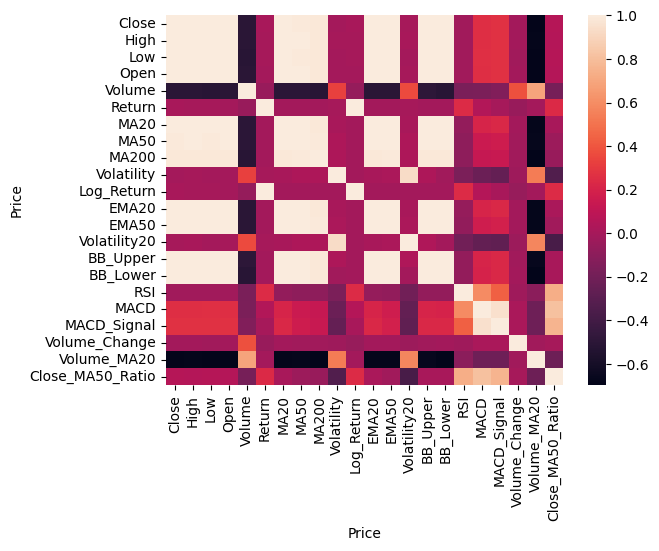

In [41]:
sns.heatmap(df.corr())

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


In [47]:
split = int(len(df) * 0.8)

new_df = df[:split]
test_df = df[split:]

In [48]:
split = int(len(new_df) * 0.8)

train_df = new_df[:split]
val_df = new_df[split:]

In [50]:
train_scaled = scaler.fit_transform(train_df[features])
val_scaled= scaler.transform(val_df[features])
test_scaled = scaler.transform(test_df[features])

In [51]:
def create_sequences(data, target_col, window_size=60):

    X = []
    y = []

    for i in range(window_size, len(data)):

        X.append(
            data[i-window_size:i]
        )

        y.append(
            data[i, target_col]
        )

    return np.array(X), np.array(y)
target_idx = features.index('Close')

In [52]:
X_train, y_train = create_sequences(
    train_scaled,
    target_idx,
    60
)
X_val, y_val = create_sequences(
    val_scaled,
    target_idx,
    60
)

X_test, y_test = create_sequences(
    test_scaled,
    target_idx,
    60
)

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential([
    SimpleRNN(
        64,
        input_shape=(60, len(features))
    ),

    Dense(32, activation='relu'),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    LSTM(
        64,
        input_shape=(60, len(features))
    ),

    Dense(32, activation='relu'),

    Dense(1)
])

In [55]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    GRU(
        64,
        input_shape=(60, len(features))
    ),

    Dense(32, activation='relu'),

    Dense(1)
])

In [56]:
for model in [
    rnn_model,
    lstm_model,
    gru_model
]:

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

In [57]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=5,
        factor=0.5
    )
]

In [58]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0289 - mae: 0.1044 - val_loss: 0.0060 - val_mae: 0.0682 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0024 - mae: 0.0353 - val_loss: 0.0016 - val_mae: 0.0336 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014 - mae: 0.0276 - val_loss: 0.0018 - val_mae: 0.0356 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.8673e-04 - mae: 0.0232 - val_loss: 0.0017 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.6432e-04 - mae: 0.0208 - val_loss: 0.0014 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.6512e-04 - mae: 0.0175 - val_loss: 0.0011 - val_mae: 0.0263 - learning_rate: 0.0010
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.4199e-04 - mae: 0.0153 - val_loss: 9.8995e-04 - val_mae: 0.0249 - learning_rate: 0.0010

In [60]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0130 - mae: 0.0656 - val_loss: 0.0057 - val_mae: 0.0689 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.7393e-04 - mae: 0.0140 - val_loss: 0.0018 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.9652e-04 - mae: 0.0132 - val_loss: 0.0021 - val_mae: 0.0395 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.7263e-04 - mae: 0.0131 - val_loss: 0.0013 - val_mae: 0.0294 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.3234e-04 - mae: 0.0123 - val_loss: 0.0011 - val_mae: 0.0271 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.8986e-04 - mae: 0.0110 - val_loss: 0.0011 - val_mae: 0.0267 - learning_rate: 5.0000e-04
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.9591e-04 - mae: 0.0113 - val_loss: 0.0011 - val_mae: 0.0278 - learning_r

In [59]:
history_rnn = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0055 - mae: 0.0419 - val_loss: 0.0037 - val_mae: 0.0552 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.7772e-04 - mae: 0.0137 - val_loss: 7.3110e-04 - val_mae: 0.0222 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5622e-04 - mae: 0.0109 - val_loss: 5.6860e-04 - val_mae: 0.0193 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2534e-04 - mae: 0.0104 - val_loss: 5.5515e-04 - val_mae: 0.0191 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.0051e-04 - mae: 0.0099 - val_loss: 4.8979e-04 - val_mae: 0.0181 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.8938e-04 - mae: 0.0096 - val_loss: 4.6272e-04 - val_mae: 0.0176 - learning_rate: 0.0010
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7450e-04 - mae: 0.0090 - val_loss: 4.6897e-04 - val_mae: 0.

In [61]:
rnn_pred = rnn_model.predict(X_test)

lstm_pred = lstm_model.predict(X_test)

gru_pred = gru_model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [62]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [73]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [76]:
rnn_metrics = evaluate_model(
    y_test,
    rnn_pred
)

lstm_metrics = evaluate_model(
    y_test,
    lstm_pred
)

gru_metrics = evaluate_model(
    y_test,
    gru_pred
)

In [77]:
results = pd.DataFrame([
    {
        "Model": "RNN",
        **rnn_metrics
    },

    {
        "Model": "LSTM",
        **lstm_metrics
    },

    {
        "Model": "GRU",
        **gru_metrics
    }
])

results

,Model,MAE,MSE,RMSE,R2,MAPE
0,RNN,0.145642,0.032909,0.181408,0.014966,12.756878
1,LSTM,0.361422,0.144588,0.380247,-3.327840,25.479295
2,GRU,0.101875,0.013971,0.118201,0.581803,13.548600


In [71]:
results

,Model,MAE,RMSE,R2


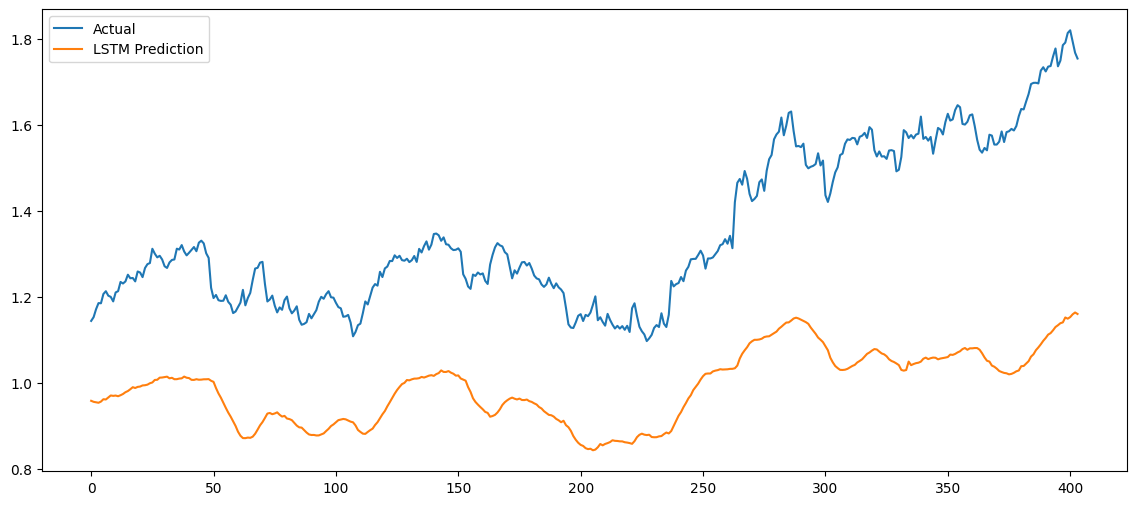

In [68]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test,
    label='Actual'
)

plt.plot(
    lstm_pred,
    label='LSTM Prediction'
)

plt.legend()

plt.show()

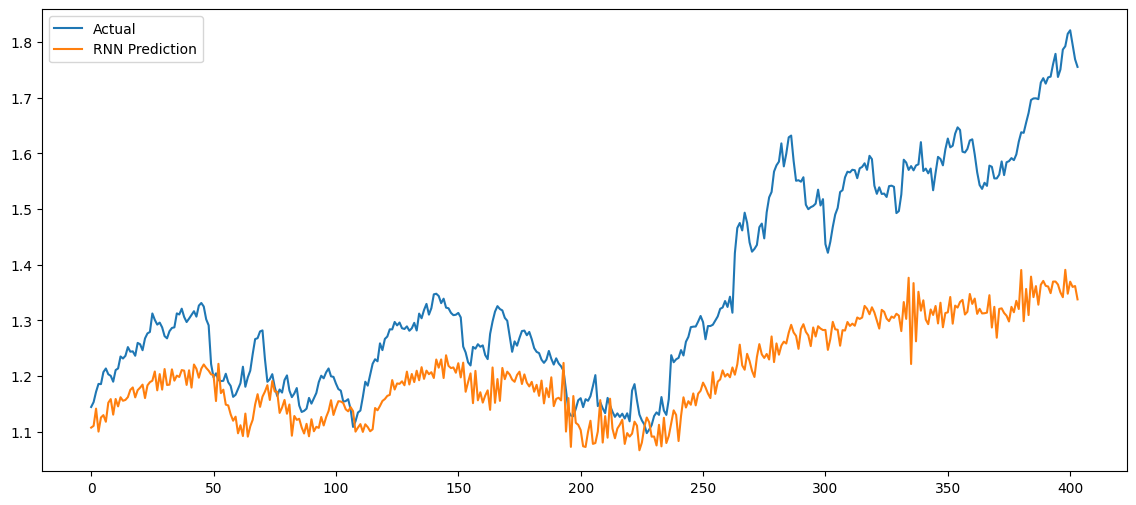

In [69]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test,
    label='Actual'
)

plt.plot(
    rnn_pred,
    label='RNN Prediction'
)

plt.legend()

plt.show()

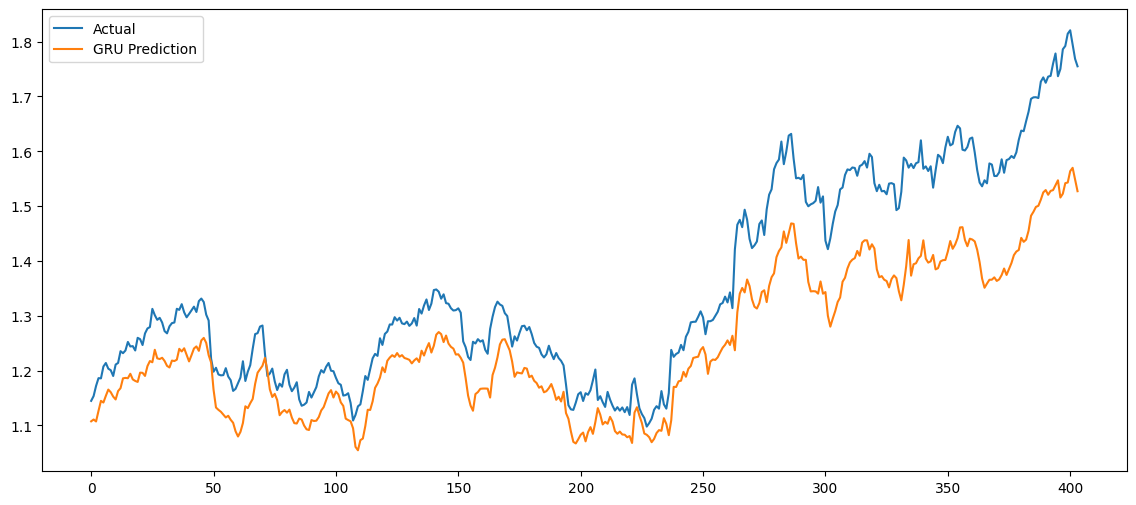

In [70]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test,
    label='Actual'
)

plt.plot(
    gru_pred,
    label='GRU Prediction'
)

plt.legend()

plt.show()

In [78]:
rnn_model.save('rnn_model.h5')
lstm_model.save('lstm_model.h5')
gru_model.save('gru_model.h5')